# RGB Colour Thresholding — Banana Ripeness Classification
### Section 3.1.3 Methodology Implementation

This notebook implements the RGB Colour Thresholding pipeline described in Section 3.1.3 of the assignment:

**Input image → Resize → Median filtering → RGB colour normalisation → adaptive per-image R–G–B distance thresholding → Banana-region extraction → RGB colour-histogram feature extraction → Classifier → Ripeness class**

Dataset: [Banana Ripeness Classification Dataset](https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset) (Kaggle), expected layout:

In [2]:
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

%matplotlib inline


## 1. Configuration

Change `DATA_ROOT` to point at your full dataset folder (containing `train`/`valid`/`test`) to reproduce results on all 13,478 images.

In [4]:
DATA_ROOT = r"C:\Users\User\archive\Banana Ripeness Classification Dataset"

CLASSES = ["unripe", "ripe", "overripe", "rotten"]
IMG_SIZE = (416, 416)          # resize target
MEDIAN_KERNEL = 3               # 3x3 median filter
HIST_BINS = 16                  # bins per channel for RGB histogram
MORPH_KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))


## 2. Pre-processing

**3.1.3.1 Median filtering** reduces visible image noise while preserving banana boundaries.

**3.1.3.2 RGB colour normalisation** converts each pixel to chromaticity coordinates `r = R/(R+G+B)`, `g = G/(R+G+B)`, `b = B/(R+G+B)`, reducing sensitivity to overall brightness (raw RGB mixes brightness and colour information, unlike HSV/CIELAB/YCbCr).

In [6]:
def load_and_resize(path, size=IMG_SIZE):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img


def median_filter(img, k=MEDIAN_KERNEL):
    """3.1.3.1 Median filtering for image-noise reduction."""
    return cv2.medianBlur(img, k)


def normalise_rgb(img):
    """
    3.1.3.2 RGB colour normalisation for lighting variation.
    r = R/(R+G+B), g = G/(R+G+B), b = B/(R+G+B)
    Returned as float32 in [0, 1].
    """
    img_f = img.astype(np.float32)
    total = img_f.sum(axis=2, keepdims=True) + 1e-6
    norm = img_f / total
    return norm  # shape (H, W, 3), channels = r, g, b in [0,1]


## 3. Segmentation — Adaptive R–G–B Distance Thresholding
This version instead computes an **adaptive threshold per image**: for each photo, it samples that photo's own border pixels as an estimate of *that photo's* background colour (bananas in this dataset are centred, not touching the frame edge), then keeps whichever pixels are far enough from that background colour in normalised-RGB space. It's still R-G-B colour thresholding — the decision boundary is still an RGB colour-distance cutoff — just computed per image instead of once for the whole dataset, so it adapts to each photo's own background instead of assuming one background colour fits all.

In [8]:
SEG_TAU = 0.10             # normalised-RGB distance cutoff from background
SEG_BORDER_FRAC = 0.06      # width of the border strip sampled as background


SEG_BLACK_CUT = 25  # pixels this dark in the border strip are treated as
                     # rotation padding, not real background, and dropped


def estimate_background_color(img, border_frac=SEG_BORDER_FRAC, black_cut=SEG_BLACK_CUT):
    h, w = img.shape[:2]
    bx, by = max(1, int(w * border_frac)), max(1, int(h * border_frac))
    border_pixels = np.concatenate([
        img[:by, :].reshape(-1, 3),
        img[-by:, :].reshape(-1, 3),
        img[:, :bx].reshape(-1, 3),
        img[:, -bx:].reshape(-1, 3),
    ], axis=0).astype(np.float32)
    not_padding = border_pixels.max(axis=1) > black_cut
    if not_padding.sum() > 20:
        border_pixels = border_pixels[not_padding]
    return np.median(border_pixels, axis=0)  # (R, G, B)


def segment_banana(img, tau=SEG_TAU):
    """3.1.3.3 Adaptive R-G-B distance thresholding + morphological refinement."""
    bg_color = estimate_background_color(img)
    bg_norm = bg_color / (bg_color.sum() + 1e-6)

    norm = normalise_rgb(img)
    dist = np.linalg.norm(norm - bg_norm.reshape(1, 1, 3), axis=2)

    mask = (dist > tau).astype(np.uint8) * 255

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, MORPH_KERNEL)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, MORPH_KERNEL)

    # Keep only the largest connected component (the banana)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(labels == largest, 255, 0).astype(np.uint8)

    return mask


## 4. Feature Extraction — RGB Colour Histogram

**3.1.3.4** 16-bin-per-channel RGB histogram of the segmented banana region, L1-normalised into a 48-length feature vector.

In [10]:
def extract_rgb_histogram(img, mask, bins=HIST_BINS):
    """3.1.3.4 RGB histogram features for colour similarity."""
    feats = []
    for c in range(3):  # R, G, B
        hist = cv2.calcHist([img], [c], mask, [bins], [0, 256]).flatten()
        feats.append(hist)
    feats = np.concatenate(feats).astype(np.float32)
    total = feats.sum()
    if total > 0:
        feats /= total
    return feats  # length 48 (16 x 3)


def process_image(path):
    img = load_and_resize(path)
    img = median_filter(img)
    mask = segment_banana(img)
    frac = (mask > 0).sum() / mask.size
    # Fallback if segmentation collapses to near-nothing OR balloons to
    # near-everything (the second case is the background-instead-of-banana
    # failure mode) -- in either case the mask isn't telling us anything
    # useful, so fall back to the whole image rather than trust it.
    if frac < 0.02 or frac > 0.90:
        mask = np.full(img.shape[:2], 255, dtype=np.uint8)
    feats = extract_rgb_histogram(img, mask)
    return feats, mask


## 5. Dataset Loading

In [12]:
def list_split(data_root, split):
    root = Path(data_root) / split
    paths, labels = [], []
    for cls in CLASSES:
        cls_dir = root / cls
        if not cls_dir.exists():
            continue
        for p in cls_dir.iterdir():
            if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp"):
                paths.append(p)
                labels.append(cls)
    return paths, labels


def build_feature_matrix(paths, desc=""):
    X, valid_idx, times = [], [], []
    for i, p in enumerate(paths):
        t0 = time.perf_counter()
        try:
            feats, _ = process_image(p)
        except ValueError:
            continue
        times.append(time.perf_counter() - t0)
        X.append(feats)
        valid_idx.append(i)
        if (i + 1) % 500 == 0:
            print(f"  [{desc}] processed {i + 1}/{len(paths)}")
    if not X:
        return np.empty((0, HIST_BINS * 3), dtype=np.float32), valid_idx, times
    return np.array(X), valid_idx, times


train_paths, train_labels = list_split(DATA_ROOT, "train")
valid_paths, valid_labels = list_split(DATA_ROOT, "valid")
test_paths, test_labels = list_split(DATA_ROOT, "test")

print(f"train={len(train_paths)}  valid={len(valid_paths)}  test={len(test_paths)}")


train=11793  valid=1123  test=562


## 5.5 Dataset Distribution

Class distribution across the original train / validation / test split (unchanged), shown as a table and a bar chart for the same comparison the group's other colour-space notebooks report.

,train,valid,test,Total
unripe,1902,167,110,2179
ripe,3522,339,154,4015
overripe,2349,229,113,2691
rotten,4020,388,185,4593
Total,11793,1123,562,13478


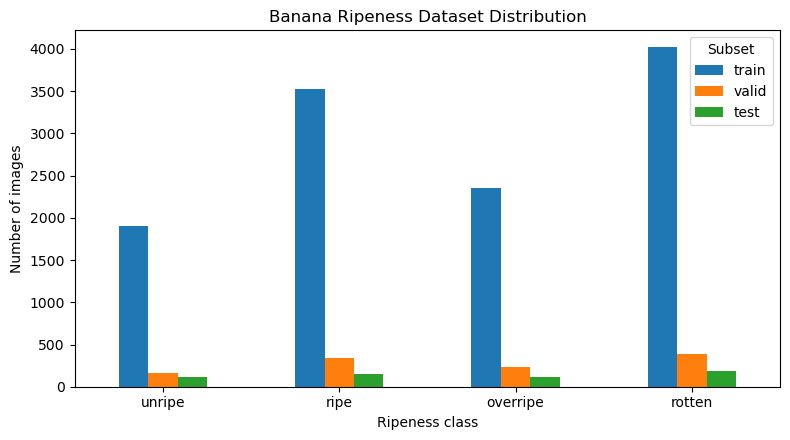

In [14]:
dist_table = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts(),
    "valid": pd.Series(valid_labels).value_counts(),
    "test": pd.Series(test_labels).value_counts(),
}).reindex(CLASSES).fillna(0).astype(int)
dist_table["Total"] = dist_table.sum(axis=1)
dist_table.loc["Total"] = dist_table.sum(axis=0)
display(dist_table)

ax = dist_table.drop(index="Total").drop(columns="Total").plot(kind="bar", figsize=(8, 4.5))
ax.set_title("Banana Ripeness Dataset Distribution")
ax.set_xlabel("Ripeness class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=0)
plt.legend(title="Subset")
plt.tight_layout()
plt.show()

## 6. Sample Images (Before Processing)

Raw images from each class, shown before resizing/filtering/segmentation.

Note: `cls_paths[0]` (whichever file happens to come first alphabetically in that class's folder) has no relationship to how visually representative that photo is -- this dataset's `rotten` class in particular mixes genuinely dark/rotten photos in with barely-spotted, more "ripe"-looking ones. `pick_typical_example` below instead looks at the first several files per class and picks one with moderately low brightness, which tends to land on a more visually typical specimen of that ripeness stage. It's used here AND in the segmentation preview in Section 7, so both show the same example per class.

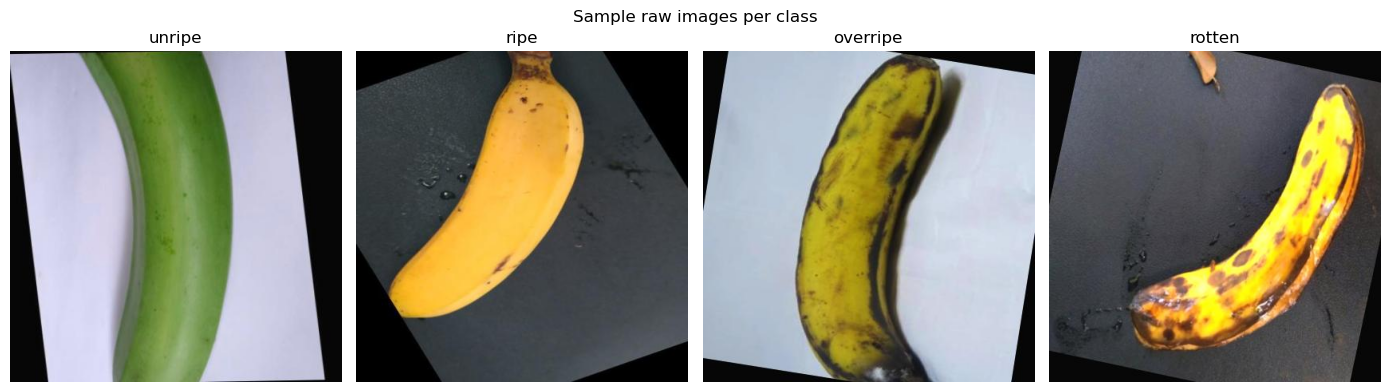

In [37]:
def pick_typical_example(cls_paths, n_candidates=20):
    """Pick a representative example from the first few files in a class
    by choosing one with below-median brightness -- avoids always landing
    on an atypical/ambiguous first-alphabetical file."""
    candidates = cls_paths[:n_candidates]
    if len(candidates) <= 1:
        return candidates[0]
    brightness = [load_and_resize(p).mean() for p in candidates]
    order = np.argsort(brightness)  # dimmest first
    return candidates[order[len(order) // 3]]  # a moderately dark example


fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cls in zip(axes, CLASSES):
    cls_paths = [p for p, l in zip(train_paths, train_labels) if l == cls]
    if cls_paths:
        img = load_and_resize(pick_typical_example(cls_paths))
        ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample raw images per class")
plt.tight_layout()
plt.show()


## 7. Segmentation Preview

No training-time threshold estimation step is needed any more — the adaptive threshold is computed independently for each image (train or test) at the moment it's processed, from that image's own border pixels. This cell just previews the resulting masks on the same example per class picked in Section 6.

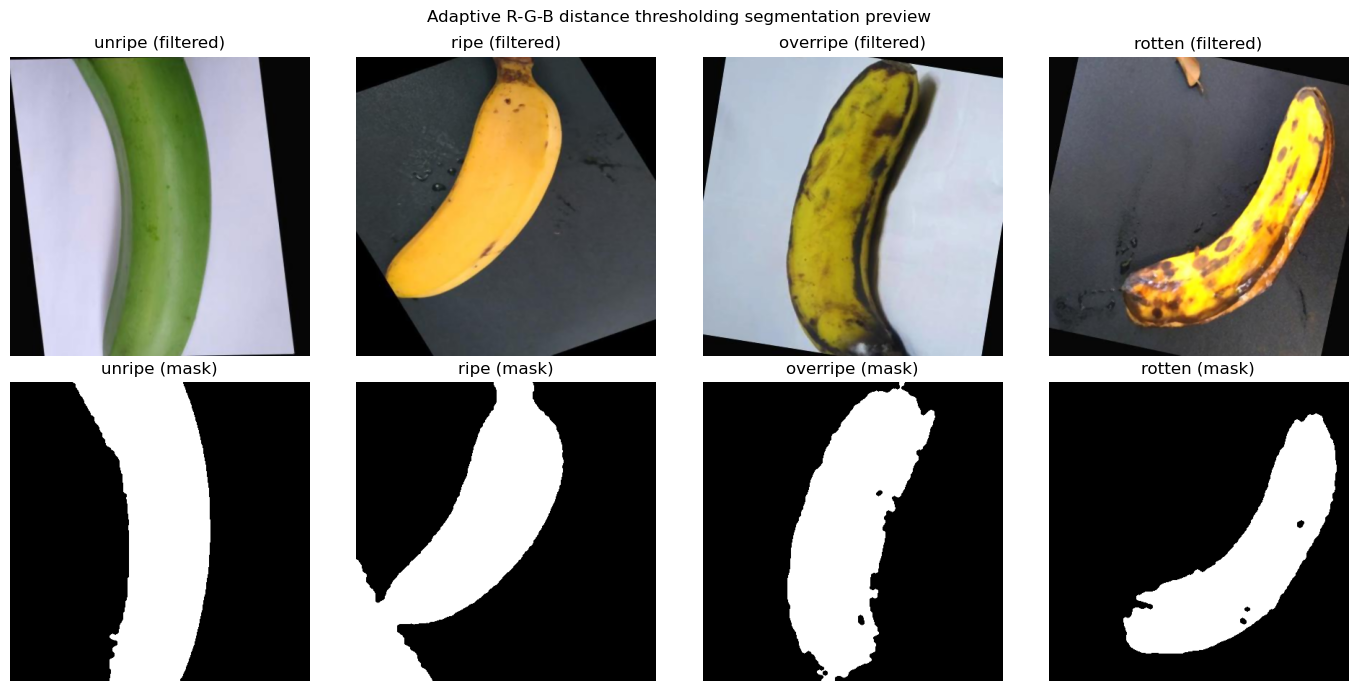

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, cls in enumerate(CLASSES):
    cls_paths = [p for p, l in zip(train_paths, train_labels) if l == cls]
    if not cls_paths:
        continue
    example_path = pick_typical_example(cls_paths)
    img = load_and_resize(example_path)
    img_f = median_filter(img)
    mask = segment_banana(img_f)
    axes[0, col].imshow(img_f)
    axes[0, col].set_title(f"{cls} (filtered)")
    axes[0, col].axis("off")
    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title(f"{cls} (mask)")
    axes[1, col].axis("off")
plt.suptitle("Adaptive R-G-B distance thresholding segmentation preview")
plt.tight_layout()
plt.show()


## 7.5 Worked Single-Image Example

Worked examples for one representative training image from each of the four ripeness classes are given below, walking through every stage the pipeline applies to each photo -- this is the RGB-side equivalent of the "worked example" step-by-step breakdown used elsewhere in the report.

,class,image,background_RGB,foreground_fraction,feature_vector_length,classifier_prediction
0,unripe,musa-acuminata-freshunripe-18f6ed60-2653-11ec-...,"(182.0, 181.0, 207.0)",0.2851,48,(run Section 8 first)
1,ripe,musa-acuminata-banana-ad628aed-394a-11ec-8ccd-...,"(57.0, 63.0, 65.0)",0.2802,48,(run Section 8 first)
2,overripe,musa-acuminata-mold-e191c16b-1d0a-11ec-8780-d8...,"(179.0, 193.0, 209.0)",0.2612,48,(run Section 8 first)
3,rotten,musa-acuminata-banana-8b6bc840-394a-11ec-b09c-...,"(68.0, 68.0, 70.0)",0.2178,48,(run Section 8 first)


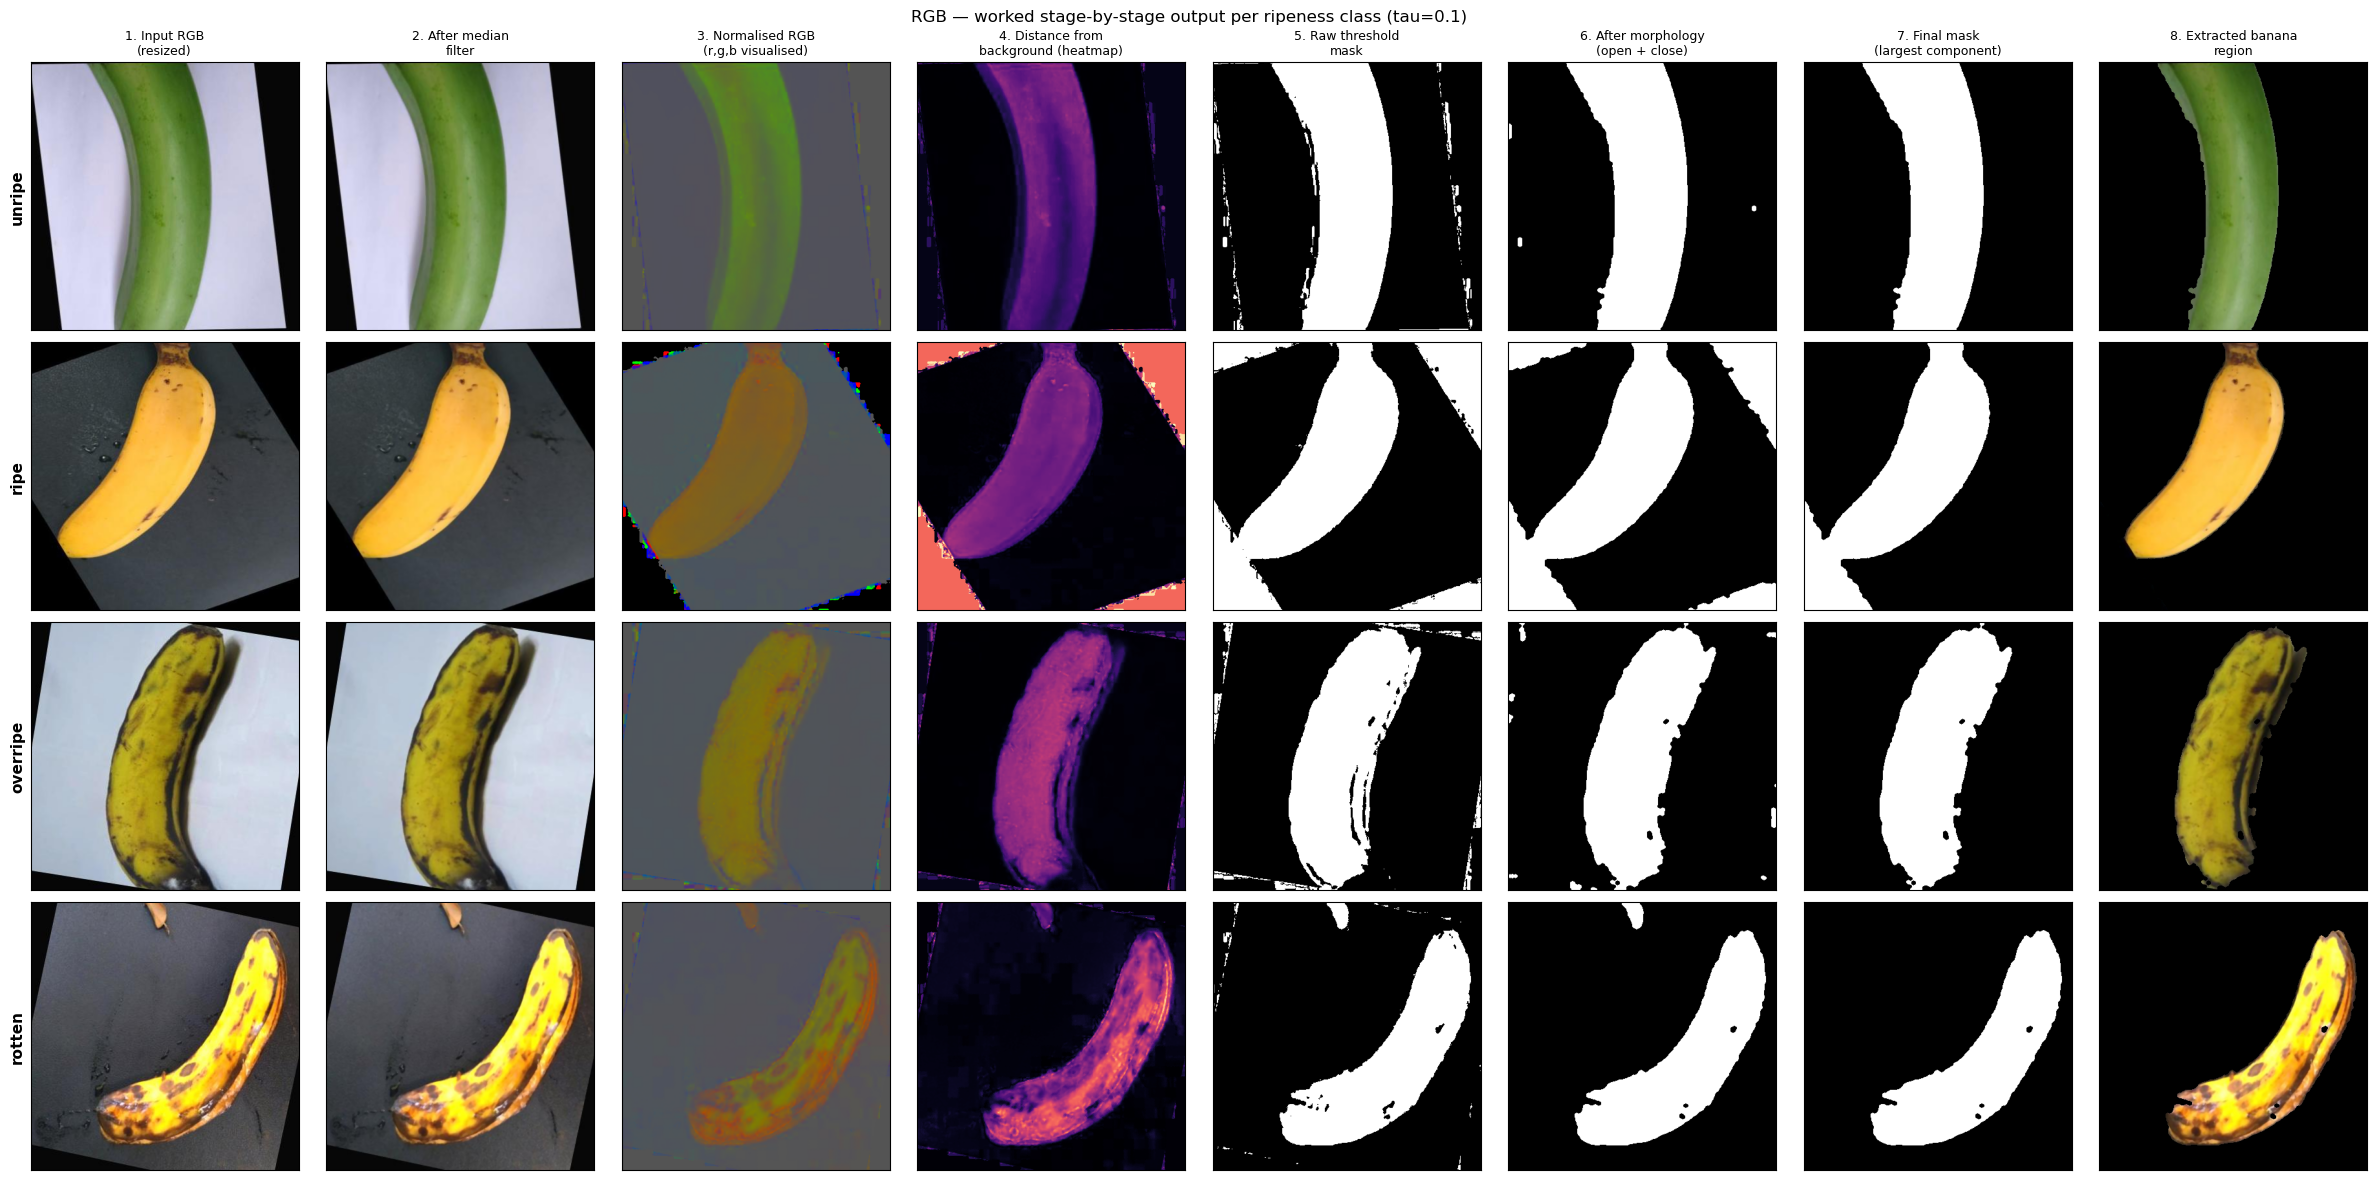

In [39]:
worked_examples = {}
for cls in CLASSES:
    cls_paths = [p for p, l in zip(train_paths, train_labels) if l == cls]
    worked_path = pick_typical_example(cls_paths)

    img_raw = load_and_resize(worked_path)
    img_f = median_filter(img_raw)

    bg_color = estimate_background_color(img_f)
    bg_norm = bg_color / (bg_color.sum() + 1e-6)
    norm = normalise_rgb(img_f)
    dist = np.linalg.norm(norm - bg_norm.reshape(1, 1, 3), axis=2)

    raw_mask = (dist > SEG_TAU).astype(np.uint8) * 255
    opened = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, MORPH_KERNEL)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, MORPH_KERNEL)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    if n_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        final_mask = np.where(labels == largest, 255, 0).astype(np.uint8)
    else:
        final_mask = closed

    extracted = img_f.copy()
    extracted[final_mask == 0] = 0

    fg_fraction = (final_mask > 0).sum() / final_mask.size
    worked_feats = extract_rgb_histogram(img_f, final_mask)

    worked_examples[cls] = {
        "path": worked_path,
        "bg_color": bg_color,
        "fg_fraction": fg_fraction,
        "feats": worked_feats,
        "stage_imgs": [
            (img_raw, "1. Input RGB\n(resized)"),
            (img_f, "2. After median\nfilter"),
            ((norm * 255).astype(np.uint8), "3. Normalised RGB\n(r,g,b visualised)"),
            (dist, "4. Distance from\nbackground (heatmap)"),
            (raw_mask, "5. Raw threshold\nmask"),
            (closed, "6. After morphology\n(open + close)"),
            (final_mask, "7. Final mask\n(largest component)"),
            (extracted, "8. Extracted banana\nregion"),
        ],
    }

# Summary table: background estimate, foreground fraction and (if Section 8
# has already been run) the classifier's prediction for each worked example.
summary_rows = []
for cls in CLASSES:
    info = worked_examples[cls]
    row = {
        "class": cls,
        "image": info["path"].name,
        "background_RGB": tuple(np.round(info["bg_color"], 1)),
        "foreground_fraction": round(info["fg_fraction"], 4),
        "feature_vector_length": len(info["feats"]),
    }
    try:
        pred = clf.predict(scaler.transform(info["feats"].reshape(1, -1)))
        row["classifier_prediction"] = le.inverse_transform(pred)[0]
    except NameError:
        row["classifier_prediction"] = "(run Section 8 first)"
    summary_rows.append(row)
display(pd.DataFrame(summary_rows))

fig, axes = plt.subplots(len(CLASSES), 8, figsize=(24, 3 * len(CLASSES)))
for row, cls in enumerate(CLASSES):
    for col, (im, title) in enumerate(worked_examples[cls]["stage_imgs"]):
        ax = axes[row, col]
        if im.ndim == 2 and im.dtype != np.uint8:
            ax.imshow(im, cmap="magma")
        elif im.ndim == 2:
            ax.imshow(im, cmap="gray")
        else:
            ax.imshow(im)
        if row == 0:
            ax.set_title(title, fontsize=9)
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
plt.suptitle(f"RGB — worked stage-by-stage output per ripeness class (tau={SEG_TAU})", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Feature Extraction + Classification

Group protocol (agreed across all five techniques): the final model is fit **once on the combined training + validation data**, then evaluated on the untouched test set — not fit on training data alone. Classifier is left at library defaults: `StandardScaler()` -> `SVC()`, no hyperparameter tuning, so results are comparable across everyone's colour-space technique.

In [40]:
print("Extracting features (train)...")
X_train, idx_train, t_train = build_feature_matrix(train_paths, "train")
y_train = np.array(train_labels)[idx_train]

print("Extracting features (valid)...")
X_valid, idx_valid, t_valid = build_feature_matrix(valid_paths, "valid")
y_valid = np.array(valid_labels)[idx_valid]

print("Extracting features (test)...")
X_test, idx_test, t_test = build_feature_matrix(test_paths, "test")
y_test = np.array(test_labels)[idx_test]

le = LabelEncoder().fit(CLASSES)

# Final model is fit on the COMBINED train+valid data (group protocol: an
# untuned StandardScaler() -> SVC() classifier fitted once on the combined
# training and validation data before predicting the untouched test subset).
X_trainval = np.concatenate([X_train, X_valid], axis=0)
y_trainval = np.concatenate([y_train, y_valid], axis=0)
y_trainval_enc = le.transform(y_trainval)
y_test_enc = le.transform(y_test)

scaler = StandardScaler().fit(X_trainval)
X_trainval_s = scaler.transform(X_trainval)
X_test_s = scaler.transform(X_test)

print(f"Combined train+valid samples used to fit the final model: {len(X_trainval)}")
print("Training classifier (SVM, RBF kernel, default hyperparameters)...")
clf = SVC()

t0 = time.perf_counter()
clf.fit(X_trainval_s, y_trainval_enc)
train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred = clf.predict(X_test_s)
predict_time = time.perf_counter() - t0

print("Done.")


Extracting features (train)...
  [train] processed 500/11793
  [train] processed 1000/11793
  [train] processed 1500/11793
  [train] processed 2000/11793
  [train] processed 2500/11793
  [train] processed 3000/11793
  [train] processed 3500/11793
  [train] processed 4000/11793
  [train] processed 4500/11793
  [train] processed 5000/11793
  [train] processed 5500/11793
  [train] processed 6000/11793
  [train] processed 6500/11793
  [train] processed 7000/11793
  [train] processed 7500/11793
  [train] processed 8000/11793
  [train] processed 8500/11793
  [train] processed 9000/11793
  [train] processed 9500/11793
  [train] processed 10000/11793
  [train] processed 10500/11793
  [train] processed 11000/11793
  [train] processed 11500/11793
Extracting features (valid)...
  [valid] processed 500/1123
  [valid] processed 1000/1123
Extracting features (test)...
  [test] processed 500/562
Combined train+valid samples used to fit the final model: 12916
Training classifier (SVM, RBF kernel, defa

  [train] processed 500/11793


  [train] processed 1000/11793


  [train] processed 1500/11793


  [train] processed 2000/11793


...

  [valid] processed 1000/1123


Extracting features (test)...


  [test] processed 500/562


Combined train+valid samples used to fit the final model: 12916
Training classifier (SVM, RBF kernel, default hyperparameters)...


Done.


## 8.5 Validation Checkpoint (train-only fit)

Group protocol, Phase 2: before the final combined-fit model is evaluated on the test set, a separate model is fitted on **training features only** and checked against **training** (fit quality) and **validation** (generalisation, the actual checkpoint) features. This model is not used for the Section 9 test result -- it exists only to report train/valid numbers alongside the final train+valid/test numbers.

In [41]:
print("Training validation-checkpoint classifier (train-only fit)...")
y_train_enc = le.transform(y_train)
y_valid_enc = le.transform(y_valid)

scaler_val = StandardScaler().fit(X_train)
X_train_s_val = scaler_val.transform(X_train)
X_valid_s = scaler_val.transform(X_valid)

clf_val = SVC()
clf_val.fit(X_train_s_val, y_train_enc)

y_pred_train = clf_val.predict(X_train_s_val)
y_pred_valid = clf_val.predict(X_valid_s)

print("Done.")


Training validation-checkpoint classifier (train-only fit)...
Done.


Done.


## 9. Results — Train / Validation / Test

In [42]:
def summarise(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"----- {name} -----")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Macro Precision    : {precision:.4f}")
    print(f"Macro Recall       : {recall:.4f}")
    print(f"Macro F1-score     : {f1:.4f}")
    print()
    return acc, precision, recall, f1

print("===== RGB Colour Thresholding — Results per split =====")
print(f"(Train/Valid results below use the TRAIN-ONLY-fit model; Test uses the final TRAIN+VALID-fit model, per protocol)\n")

train_acc, train_p, train_r, train_f1 = summarise("Train (n=%d, train-only fit)" % len(y_train_enc), y_train_enc, y_pred_train)
valid_acc, valid_p, valid_r, valid_f1 = summarise("Validation (n=%d, train-only fit)" % len(y_valid_enc), y_valid_enc, y_pred_valid)
test_acc, test_p, test_r, test_f1 = summarise("Test (n=%d, train+valid fit)" % len(y_test_enc), y_test_enc, y_pred)

avg_pipeline_time = float(np.mean(t_train + t_valid + t_test))
print(f"Avg per-image time : {avg_pipeline_time * 1000:.2f} ms (preprocess+segment+features)")
print(f"Train time (final model, train+valid) : {train_time:.4f} s")
print(f"Predict time (test, all)              : {predict_time:.4f} s")


===== RGB Colour Thresholding — Results per split =====
(Train/Valid results below use the TRAIN-ONLY-fit model; Test uses the final TRAIN+VALID-fit model, per protocol)

----- Train (n=11793, train-only fit) -----
Accuracy           : 0.8983
Macro Precision    : 0.9010
Macro Recall       : 0.9048
Macro F1-score     : 0.9028

----- Validation (n=1123, train-only fit) -----
Accuracy           : 0.9163
Macro Precision    : 0.9154
Macro Recall       : 0.9274
Macro F1-score     : 0.9209

----- Test (n=562, train+valid fit) -----
Accuracy           : 0.9164
Macro Precision    : 0.9194
Macro Recall       : 0.9197
Macro F1-score     : 0.9193

Avg per-image time : 39.52 ms (preprocess+segment+features)
Train time (final model, train+valid) : 7.1983 s
Predict time (test, all)              : 0.6387 s


### 9.1 Processing Time by Subset

Breaks down the preprocessing + segmentation + feature-extraction time recorded while building the feature matrices (Section 8) by subset, alongside the overall average already reported above.

In [43]:
processing_time_table = pd.DataFrame({
    "subset": ["train", "valid", "test"],
    "image_count": [len(t_train), len(t_valid), len(t_test)],
    "total_seconds": [sum(t_train), sum(t_valid), sum(t_test)],
    "mean_seconds": [np.mean(t_train), np.mean(t_valid), np.mean(t_test)],
})
display(processing_time_table)

,subset,image_count,total_seconds,mean_seconds
0,train,11793,471.773949,0.040005
1,valid,1123,40.643471,0.036192
2,test,562,20.255397,0.036042


## 10. Confusion Matrix & Per-class Report

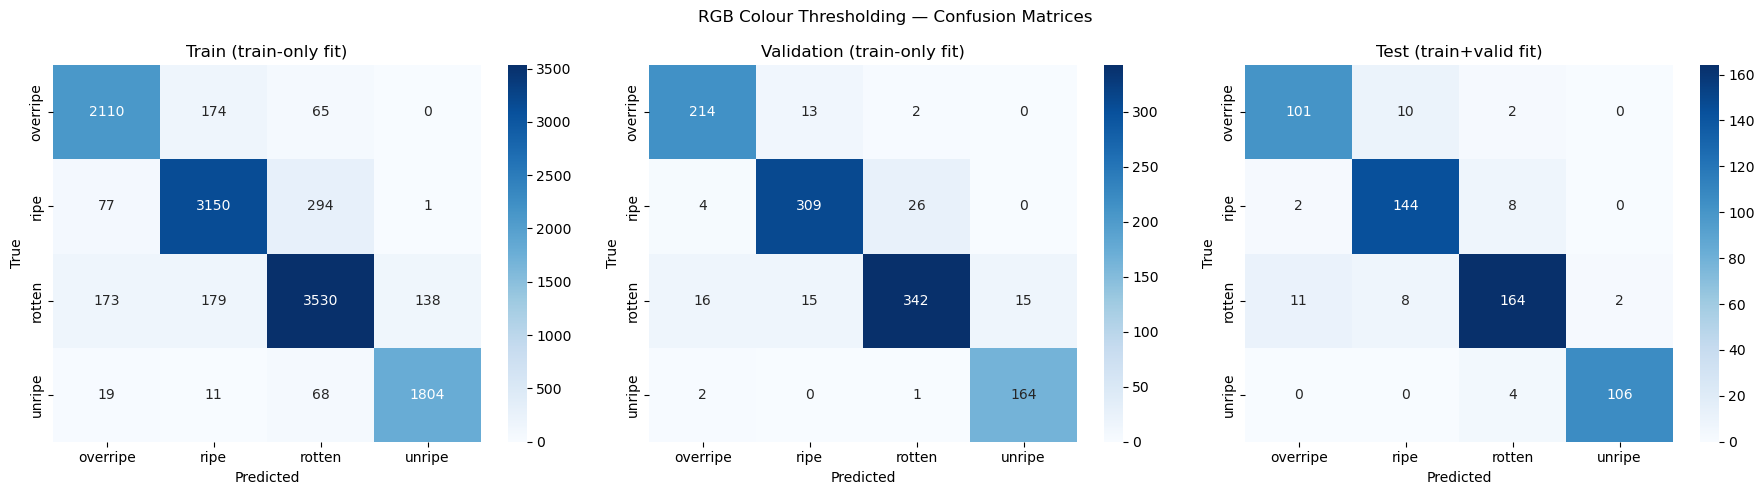

----- Train classification report -----
              precision    recall  f1-score   support

    overripe     0.8869    0.8983    0.8926      2349
        ripe     0.8964    0.8944    0.8954      3522
      rotten     0.8921    0.8781    0.8850      4020
      unripe     0.9285    0.9485    0.9384      1902

    accuracy                         0.8983     11793
   macro avg     0.9010    0.9048    0.9028     11793
weighted avg     0.8982    0.8983    0.8982     11793

----- Validation classification report -----
              precision    recall  f1-score   support

    overripe     0.9068    0.9345    0.9204       229
        ripe     0.9169    0.9115    0.9142       339
      rotten     0.9218    0.8814    0.9012       388
      unripe     0.9162    0.9820    0.9480       167

    accuracy                         0.9163      1123
   macro avg     0.9154    0.9274    0.9209      1123
weighted avg     0.9164    0.9163    0.9160      1123

----- Test classification report -----
      

In [44]:
cm_train = confusion_matrix(y_train_enc, y_pred_train)
cm_valid = confusion_matrix(y_valid_enc, y_pred_valid)
cm_test = confusion_matrix(y_test_enc, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, name in zip(
    axes,
    [cm_train, cm_valid, cm_test],
    ["Train (train-only fit)", "Validation (train-only fit)", "Test (train+valid fit)"],
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name)
plt.suptitle("RGB Colour Thresholding — Confusion Matrices")
plt.tight_layout()
plt.show()

print("----- Train classification report -----")
print(classification_report(y_train_enc, y_pred_train, target_names=le.classes_, digits=4, zero_division=0))
print("----- Validation classification report -----")
print(classification_report(y_valid_enc, y_pred_valid, target_names=le.classes_, digits=4, zero_division=0))
print("----- Test classification report -----")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_, digits=4, zero_division=0))


### 10.1 Confusion Matrices (Tabular)

In [45]:
for name, cm in [("Train", cm_train), ("Validation", cm_valid), ("Test", cm_test)]:
    print(f"----- {name} confusion matrix -----")
    display(pd.DataFrame(cm, index=[f"true_{c}" for c in le.classes_],
                          columns=[f"pred_{c}" for c in le.classes_]))

----- Train confusion matrix -----


,pred_overripe,pred_ripe,pred_rotten,pred_unripe
true_overripe,2110,174,65,0
true_ripe,77,3150,294,1
true_rotten,173,179,3530,138
true_unripe,19,11,68,1804


----- Validation confusion matrix -----


,pred_overripe,pred_ripe,pred_rotten,pred_unripe
true_overripe,214,13,2,0
true_ripe,4,309,26,0
true_rotten,16,15,342,15
true_unripe,2,0,1,164


----- Test confusion matrix -----


,pred_overripe,pred_ripe,pred_rotten,pred_unripe
true_overripe,101,10,2,0
true_ripe,2,144,8,0
true_rotten,11,8,164,2
true_unripe,0,0,4,106
